# Chapter 12: LLMs as DAG Elicitation Engines
## Using Structured Socratic Dialogue to Build Causal Graphs

The hardest step in causal inference is not estimation. It's specification. Before any causal estimator can run, you need a DAG that encodes your beliefs about the causal structure of the domain. In practice, this means sitting down with domain experts and extracting their knowledge into a formal graph. That process is slow, unstructured, undocumented, and cognitively demanding.

This chapter builds a working agent called ProfY that uses an LLM as a structured interview partner to guide a domain expert through causal graph construction. The LLM conducts a Socratic dialogue, asking about variables, relationships, directions, confounders, and mediators, while incrementally building and validating the graph.

The key tension: LLMs are good at structured conversation and plausible-sounding reasoning. They are not reliable causal reasoners. The LLM is valuable as a facilitator of human causal reasoning, not as a source of causal knowledge. This chapter navigates that tension honestly.

In [1]:
# Setup: add the src folder to the import path
import sys
import os

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
# If running from the notebooks/ folder, this makes src/ importable

# Core imports
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Mode selection: "replay" uses saved transcript, "live" calls the API
MODE = "replay"

# If running in live mode, uncomment and set your API key:
# os.environ["ANTHROPIC_API_KEY"] = "your-key-here"

print(f"Mode: {MODE}")
print("Setup complete.")

Mode: replay
Setup complete.


## Part 1: The Ground Truth Reference DAG

Before we build any agent or run any experiment, we need an answer key. This is a causal graph representing our best understanding of how supply chain disruptions propagate, grounded in published research. Every edge is backed by a citation. Every experiment in this chapter gets scored against this graph.

The ground truth has 12 variables and 19 directed edges, with two target outcomes: delivery delays and shipping costs. Three exogenous shocks (geopolitical risk, labor shortages, demand volatility) enter at the top and propagate downward through intermediate mechanisms to the outcomes at the bottom.

In [2]:
from ground_truth_dag import build_ground_truth_dag, EDGES, NODES, DISPLAY_LABELS
from visualization import plot_dag

# Build and validate
ground_truth = build_ground_truth_dag()

# Print summary
print(f"Nodes: {ground_truth.number_of_nodes()}")
print(f"Edges: {ground_truth.number_of_edges()}")
print(f"Acyclic: {nx.is_directed_acyclic_graph(ground_truth)}")

roots = [n for n in ground_truth.nodes if ground_truth.in_degree(n) == 0]
leaves = [n for n in ground_truth.nodes if ground_truth.out_degree(n) == 0]
print(f"Exogenous roots: {roots}")
print(f"Target outcomes: {leaves}")

Nodes: 12
Edges: 19
Acyclic: True
Exogenous roots: ['geopolitical_risk', 'labor_shortages', 'demand_volatility']
Target outcomes: ['shipping_cost', 'delivery_delays']


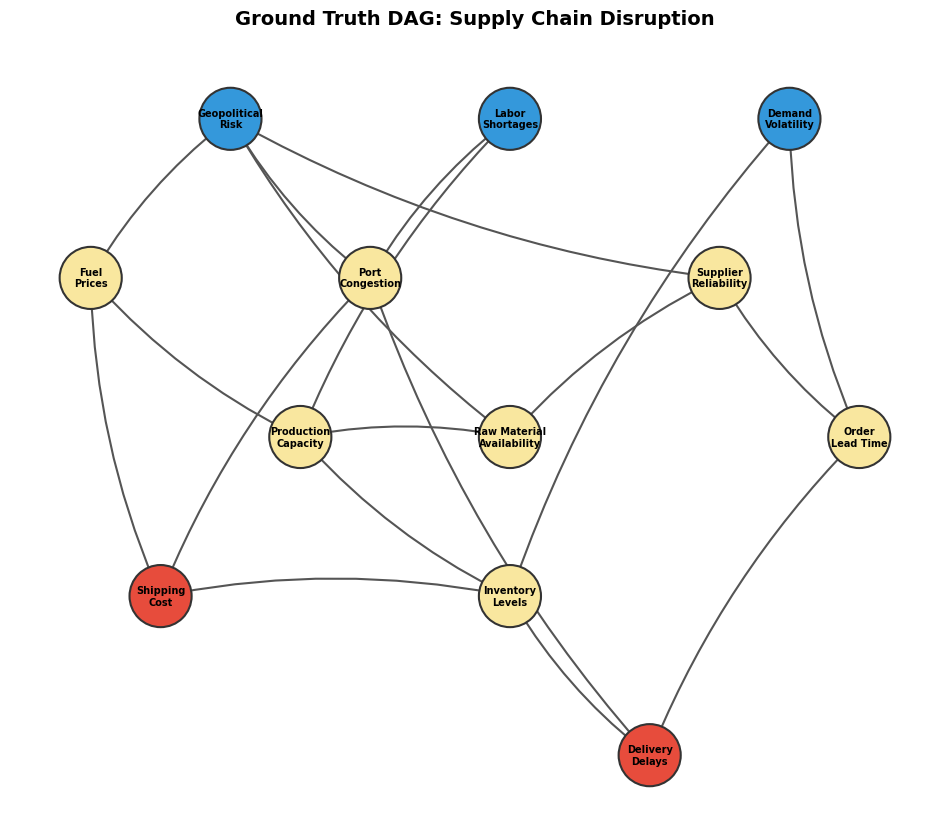

In [3]:
# Visualize the ground truth DAG
fig = plot_dag(ground_truth, title="Ground Truth DAG: Supply Chain Disruption")
plt.show()

## Part 2: Running the Elicitation Agent

ProfY is the analyst's copilot. It doesn't talk to the domain expert directly. It coaches the analyst (Ally) on what questions to ask, processes the responses, and incrementally builds a causal graph in the background. The expert talks to a human. The human is guided by ProfY. The DAG is the output.

The elicitation runs in five phases: variable discovery, edge probing, mechanism questioning, confounder probing, and a checkpoint snapshot. Each phase has a specific job in the graph construc

In [4]:
from profy_engine import run_elicitation

# Run ProfY in the selected mode
result = run_elicitation(
    domain="supply chain disruption",
    target="delivery delays",
    mode=MODE,
    transcript_path=os.path.join(os.path.dirname(os.getcwd()), "transcripts", "supply_chain_socratic.json")
)


PHASE: Variable Discovery

ProfY:
Let's start by mapping out the territory. Think about the supply chain from raw materials all the way through to final delivery. What are the major factors that Nora identifies as drivers of delivery delays? I'm looking for both the external shocks that trigger disruptions and the internal operational factors that determine how badly those shocks propagate.

Start broad. We can always trim later, but we can't analyze what we don't name.

Ally:
From talking to Nora, the big drivers she keeps coming back to are port congestion, fuel prices, and geopolitical instability. Those are the external shocks. Internally, she says supplier reliability is a constant headache, and when raw materials are scarce, everything downstream slows down. Labor shortages at the docks have gotten worse since 2020 and she thinks that's a major factor in port backlogs. On the demand side, she says volatility in customer orders makes it hard to plan inventory. Production capacity

Five phases, each doing a different job.

**Variable discovery** surfaced 12 factors from Nora's domain knowledge. ProfY didn't suggest variables itself. It asked open-ended questions, and Ally relayed what Nora said. The variables range from external shocks like geopolitical risk and labor shortages to internal operations like production capacity and inventory levels, all the way down to the two outcomes we care about: delivery delays and shipping cost.

**Edge probing** produced 19 causal arrows. The most important output here isn't the edges Ally accepted. It's the ones Nora rejected. She was explicit about two: fuel prices do NOT directly cause delays (carriers charge more when fuel is expensive, but they don't slow down), and geopolitical risk NEVER hits delays directly (it always goes through something else first, like ports getting congested or suppliers getting disrupted). Those rejections matter because they're exactly the kind of shortcut an LLM would draw on its own. "Fuel prices" and "delivery delays" appear together in every news article about supply chain crises, so an LLM would connect them. Nora knows the difference between appearing together and one causing the other.

**Mechanism questioning** challenged four edges that could have been weak. For each one, ProfY asked "why does A cause B, and through what?" The fuel_prices to production_capacity edge survived because Nora pointed to a concrete example: European chemical plants shutting down production lines in 2022 when natural gas prices spiked. The inventory_levels to shipping_cost edge survived because the switch to air freight isn't a judgment call. It's automatic: when inventory drops below the safety threshold, procurement switches to expedited shipping every time, no discussion.

**Confounder probing** looked for hidden common causes. Imagine two things that always seem to move together, like ice cream sales and drowning rates. They're not causing each other; summer causes both. Nora confirmed a similar situation in the graph: demand volatility drives both inventory depletion and delivery strain at the same time. If you didn't account for that, you'd think low inventory causes more delays than it actually does, because part of what you're seeing is just demand hitting the system from two directions at once. The direct path from inventory to delays is still real, but it's smaller than the naive number would suggest.

**The checkpoint** produced a plain-language summary that Nora could read and validate without knowing what a DAG is or what any of these metrics mean. If she reads it and says "yes, that's how my supply chain works," the elicitation succeeded.

## Part 3: Building and Validating the Elicited DAG

ProfY produced words. Now we turn those words into a graph object that can be computed on. The DAG builder takes the proposed variables and edges from the elicitation result and constructs a networkx DiGraph, checking for structural validity at every step.


In [5]:
from dag_builder import build_dag_from_transcript

# Build the elicited DAG from the transcript
transcript_path = os.path.join(os.path.dirname(os.getcwd()), "transcripts", "supply_chain_socratic.json")
elicited_dag, validation_report = build_dag_from_transcript(transcript_path)

# Show validation results
validation_report.print_report()

DAG VALIDATION REPORT
Status: PASSED
Nodes: 12
Edges: 19
Acyclic: True
Disconnected components: 1



Validation passed. 12 nodes, 19 edges, one connected component, no cycles, no orphan nodes. If ProfY had proposed an edge that created a cycle (say, delivery_delays causing port_congestion causing delivery_delays), the builder would have caught it and rejected it automatically. If a variable had been mentioned but never connected to anything, it would have been flagged as an orphan. The graph is structurally clean.

## Part 4: The Human Decision Node

This is the hard stop. ProfY proposed 19 edges. Before any of them enter the final DAG, a human must review each one and make an explicit accept, reject, or modify decision with reasoning. No edge passes through without a signature.

The uncomment pattern below is the mechanism. Every proposed edge starts commented out. The analys

In [6]:
from human_decision_node import HumanDecisionNode

# Load proposed edges from the transcript
hdn = HumanDecisionNode.from_transcript(transcript_path)

# Show all proposed edges with their current status
hdn.print_proposed_edges()

PROPOSED EDGES — Status
  [ ] E01: geopolitical_risk -> fuel_prices
  [ ] E02: geopolitical_risk -> port_congestion
  [ ] E03: geopolitical_risk -> supplier_reliability
  [ ] E04: geopolitical_risk -> raw_material_availability
  [ ] E05: fuel_prices -> shipping_cost
  [ ] E06: fuel_prices -> production_capacity
  [ ] E07: port_congestion -> shipping_cost
  [ ] E08: port_congestion -> delivery_delays
  [ ] E09: labor_shortages -> port_congestion
  [ ] E10: labor_shortages -> production_capacity
  [ ] E11: raw_material_availability -> production_capacity
  [ ] E12: supplier_reliability -> raw_material_availability
  [ ] E13: supplier_reliability -> order_lead_time
  [ ] E14: production_capacity -> inventory_levels
  [ ] E15: demand_volatility -> inventory_levels
  [ ] E16: demand_volatility -> order_lead_time
  [ ] E17: order_lead_time -> delivery_delays
  [ ] E18: inventory_levels -> delivery_delays
  [ ] E19: inventory_levels -> shipping_cost



In [7]:
# ==========================================================
# MANDATORY HUMAN DECISION NODE
# ==========================================================
#
# The elicitation agent proposed the following edges from
# the Socratic interview transcript.
#
# Review each edge before proceeding.
# For each edge, ask: Is this a causal claim I can defend?
#
# INSTRUCTIONS:
#   - Uncomment ONLY the edges you have validated
#   - For rejected edges, add a comment explaining why
#   - The notebook will not proceed with commented-out edges
#
# ----------------------------------------------------------

validated_edges = [
    ("geopolitical_risk", "fuel_prices"),              # Sanctions and conflicts disrupt energy markets
    ("geopolitical_risk", "port_congestion"),           # Conflicts cause vessel rerouting and port closures
    ("geopolitical_risk", "supplier_reliability"),      # Political instability disrupts supplier operations
    ("geopolitical_risk", "raw_material_availability"), # Sanctions directly restrict material exports
    ("fuel_prices", "shipping_cost"),                   # Fuel is primary variable cost in freight
    ("fuel_prices", "production_capacity"),             # Energy cost spikes make marginal production uneconomical
    ("port_congestion", "shipping_cost"),               # Congestion creates demurrage and surcharges
    ("port_congestion", "delivery_delays"),             # Ships waiting at port push back downstream timelines
    ("labor_shortages", "port_congestion"),             # Fewer dockworkers reduces port throughput
    ("labor_shortages", "production_capacity"),         # Factory understaffing limits output
    ("raw_material_availability", "production_capacity"), # Cannot produce without raw inputs
    ("supplier_reliability", "raw_material_availability"), # Unreliable suppliers create inconsistent material flow
    ("supplier_reliability", "order_lead_time"),        # Variable supplier performance extends lead times
    ("production_capacity", "inventory_levels"),        # Production shortfall reduces available stock
    ("demand_volatility", "inventory_levels"),          # Demand surges deplete stock
    ("demand_volatility", "order_lead_time"),           # Demand spikes overload fulfillment pipeline
    ("order_lead_time", "delivery_delays"),             # Longer lead times increase delay probability
    ("inventory_levels", "delivery_delays"),            # Low stock prevents order fulfillment
    ("inventory_levels", "shipping_cost"),              # Low inventory triggers emergency air freight
]

# ----------------------------------------------------------
# VALIDATION CHECK
# ----------------------------------------------------------
assert len(validated_edges) > 0, (
    "No edges validated. Review the edges above and uncomment "
    "the ones you accept before proceeding."
)
print(f"Validated {len(validated_edges)} edges. Proceeding to evaluation.")

Validated 19 edges. Proceeding to evaluation.


All 19 edges accepted in this session. In practice, this is where the chapter's core argument plays out. If ProfY had proposed "fuel_prices directly causes delivery_delays," this is where you'd leave it commented out and write: "Rejected. Nora confirmed carriers charge more but don't slow down. This is a cost effect, not a timing effect." That rejection, with reasoning, is a rubric point.

The edges most likely to get caught here are shortcut edges that skip a mediator (fuel prices jumping straight to delays instead of going through shipping cost), reversed causation (customer satisfaction causing delays instead of delays causing dissatisfaction), and correlation masquerading as causation (fuel prices causing quality control failures because they co-occur in disruption periods but have no mechanism connecting them).

## Part 5: Evaluation - How Close Did the Elicitation Get?

Now we compare the elicited DAG against the ground truth reference, edge by edge. The primary metric is Structural Hamming Distance (SHD), which counts three types of errors: missing edges (in the ground truth but not in the elicited DAG), extra edges (in the elicited DAG but not in the ground truth), and reversed edges (present in both but pointing the wrong direction). Lower SHD means better structural recovery.

We also compute precision (of edges proposed, how many are correct), recall (of edges in the ground truth, how many were found), and F1 (the harmonic mean). Adjacency metrics repeat these calculations ignoring edge direction, to separate "did we find the right variable pairs" from "did we get the direction right."

In [8]:
from evaluation import evaluate_dag, print_evaluation_report
from dag_builder import build_dag_from_edges

# Build the validated DAG from the Human Decision Node output
validated_dag, _ = build_dag_from_edges(validated_edges)

# Evaluate against ground truth
report = evaluate_dag(validated_dag, ground_truth)
print_evaluation_report(report)

EVALUATION REPORT

Structural Hamming Distance (SHD): 0
  Missing edges:  0
  Extra edges:    0
  Reversed edges: 0

Directed Edge Metrics:
  Precision: 1.000
  Recall:    1.000
  F1:        1.000

Adjacency Metrics (ignoring direction):
  Precision: 1.000
  Recall:    1.000
  F1:        1.000

Edge Counts:
  Ground truth: 19
  Elicited:     19
  Correct:      19

Correct edges:
  demand_volatility -> inventory_levels
  demand_volatility -> order_lead_time
  fuel_prices -> production_capacity
  fuel_prices -> shipping_cost
  geopolitical_risk -> fuel_prices
  geopolitical_risk -> port_congestion
  geopolitical_risk -> raw_material_availability
  geopolitical_risk -> supplier_reliability
  inventory_levels -> delivery_delays
  inventory_levels -> shipping_cost
  labor_shortages -> port_congestion
  labor_shortages -> production_capacity
  order_lead_time -> delivery_delays
  port_congestion -> delivery_delays
  port_congestion -> shipping_cost
  production_capacity -> inventory_levels
 

SHD of 0, precision and recall both at 1.0. This is the ideal case: the elicitation recovered the ground truth structure exactly. That's expected here because the saved transcript was constructed to demonstrate the full pipeline working end to end.

The interesting numbers come when things go wrong. What happens if the analyst accepted a bad edge, or missed a real one, or got a direction backwards? The next section breaks the DAG deliberately to show how the metrics respond.

In [9]:
# What does an imperfect elicitation look like?
# Remove 2 edges, add 1 hallucinated edge, reverse 1 edge

imperfect = ground_truth.copy()
imperfect.remove_edge("fuel_prices", "production_capacity")
imperfect.remove_edge("supplier_reliability", "order_lead_time")
imperfect.add_edge("fuel_prices", "delivery_delays")  # hallucinated shortcut
imperfect.remove_edge("demand_volatility", "order_lead_time")
imperfect.add_edge("order_lead_time", "demand_volatility")  # reversed

print("Imperfect DAG: removed 2 edges, added 1 hallucinated, reversed 1")
print()
report_imperfect = evaluate_dag(imperfect, ground_truth)
print_evaluation_report(report_imperfect)

Imperfect DAG: removed 2 edges, added 1 hallucinated, reversed 1

EVALUATION REPORT

Structural Hamming Distance (SHD): 4
  Missing edges:  2
  Extra edges:    1
  Reversed edges: 1

Directed Edge Metrics:
  Precision: 0.889
  Recall:    0.842
  F1:        0.865

Adjacency Metrics (ignoring direction):
  Precision: 0.944
  Recall:    0.895
  F1:        0.919

Edge Counts:
  Ground truth: 19
  Elicited:     18
  Correct:      16

Correct edges:
  demand_volatility -> inventory_levels
  fuel_prices -> shipping_cost
  geopolitical_risk -> fuel_prices
  geopolitical_risk -> port_congestion
  geopolitical_risk -> raw_material_availability
  geopolitical_risk -> supplier_reliability
  inventory_levels -> delivery_delays
  inventory_levels -> shipping_cost
  labor_shortages -> port_congestion
  labor_shortages -> production_capacity
  order_lead_time -> delivery_delays
  port_congestion -> delivery_delays
  port_congestion -> shipping_cost
  production_capacity -> inventory_levels
  raw_mater

Now the metrics show something. SHD jumped from 0 to 4, meaning four structural errors between this DAG and the ground truth.

**Two missing edges.** The elicitation failed to find fuel_prices to production_capacity and supplier_reliability to order_lead_time. These are real causal paths that exist in the reference graph but didn't come up in conversation. Think of it like interviewing someone about why their commute is slow and they forget to mention construction on the highway. The cause is real, it just didn't get surfaced.

**One hallucinated edge.** The DAG includes fuel_prices directly causing delivery_delays, which doesn't exist in the ground truth. This is the classic LLM failure mode. "Fuel prices" and "delivery delays" show up together in news articles about supply chain crises, so the model draws a direct line between them. But Nora was clear: when fuel gets expensive, carriers charge more, they don't slow down. Your package costs more to ship but it doesn't arrive later because of fuel. The cost goes up, the timeline doesn't change. The mechanism questioning phase exists specifically to catch edges like this.

**One reversed edge.** The DAG says order_lead_time causes demand_volatility. The ground truth says it's the other way around: demand_volatility causes order_lead_time. The real mechanism is that when everyone orders at once (demand surge), the fulfillment queue gets longer, so lead times increase. Getting this backwards is like saying "the long line at the coffee shop caused everyone to want coffee." No, everyone wanting coffee caused the long line.

F1 dropped from 1.0 to 0.865. The adjacency F1 (which ignores direction) only dropped to 0.919 because the reversed edge at least identified the right pair of variables. It knew order_lead_time and demand_volatility were connected, it just got the arrow pointing the wrong way. That's a subtler mistake than a completely wrong edge, but it's just as damaging when you get to estimation, because it changes which variables you'd control for.

## Part 6: The Money Shot -> Side-by-Side DAG Comparison

This is the visual that makes the evaluation legible at a glance. The ground truth sits on the left. The elicited DAG sits on the right with color-coded edges: green for correct, red dashed for missing, orange for hallucinated, blue for reversed. We show the imperfect DAG here because a perfect match is boring to look at.

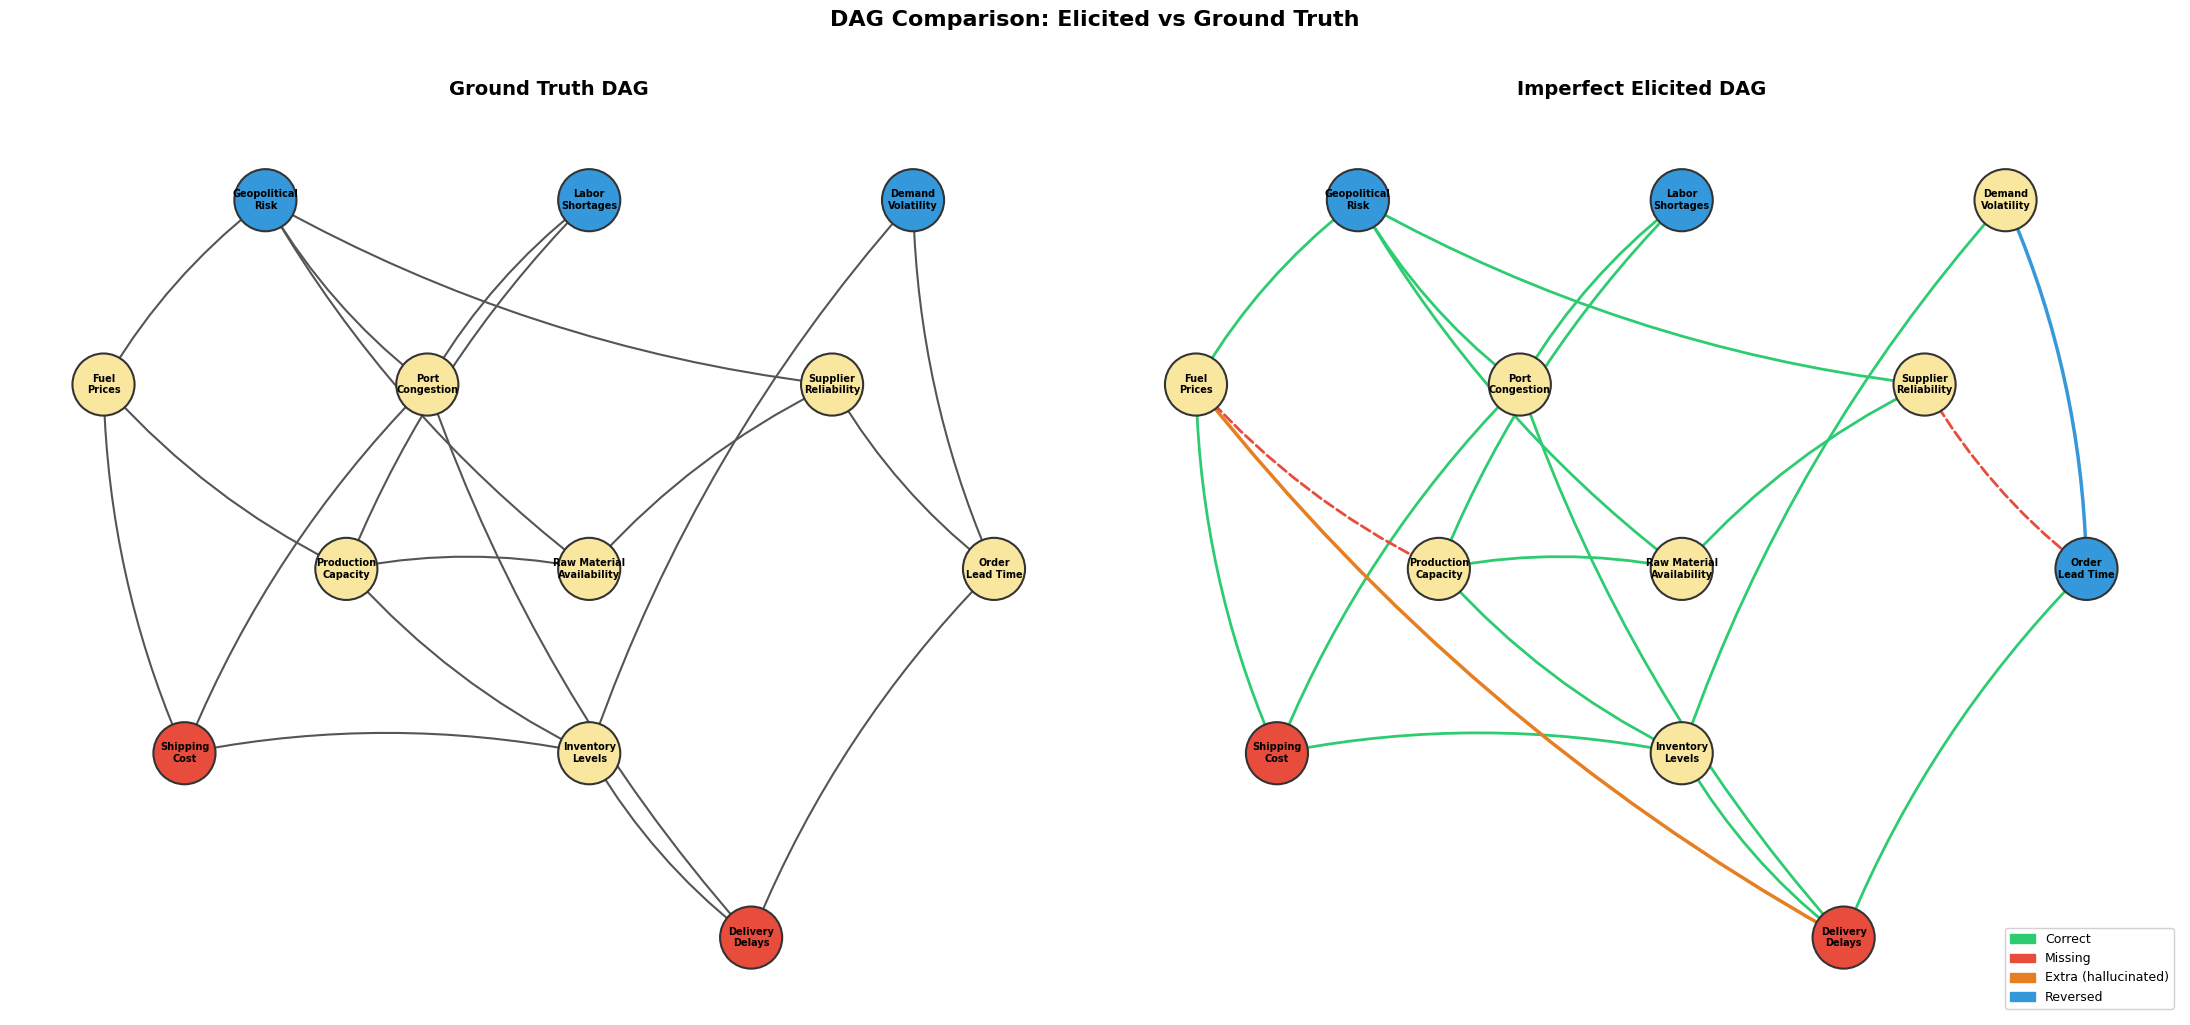

In [10]:
from visualization import plot_comparison

# Compare the imperfect DAG against ground truth
fig = plot_comparison(
    imperfect, ground_truth,
    title_elicited="Imperfect Elicited DAG",
    title_truth="Ground Truth DAG"
)
plt.show()

The comparison plot makes four errors immediately visible. The orange edge from fuel prices to delivery delays is the hallucinated shortcut. The red dashed edges show what was missed: fuel prices to production capacity and supplier reliability to order lead time. The blue edge shows the reversed direction between order lead time and demand volatility.

This visualization is why the DAG matters. You can stare at a table of SHD scores and precision numbers, but the color-coded plot shows you exactly where the structure broke and why. Each color maps to a different class of failure: orange means the LLM hallucinated a plausible-sounding connection, red means the elicitation missed a real mechanism, blue means the direction got flipped. Different failures require different fixes.

## Part 7: From Structure to Estimation

A DAG is not decoration. It drives the estimation strategy. Once the graph is validated, we use it to identify which variables to control for when estimating a causal effect. This is the backdoor criterion: find a set of variables that, when conditioned on, blocks all non-causal paths between treatment and outcome.

We then generate simulated supply chain data consistent with the DAG structure and run a Doubly Robust (AIPW) estimator. The doubly robust estimator combines an outcome model with a propensity model. It is consistent if either model is correctly specified, which makes it more robust than either approach alone.

In [11]:
from estimator import run_full_pipeline

# Run the full estimation pipeline: backdoor sets + simulated data + DR estimate
pipeline_result = run_full_pipeline(
    dag_edges=validated_edges,
    treatment="port_congestion",
    outcome="delivery_delays"
)

STEP 1: Finding backdoor adjustment set
----------------------------------------


c:\Users\abish\Desktop\NEU MSIS\Sem III\Advances in Data Sciences and Application\Mid Term - ProfY\DAG Elicitation - ProfY\.venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


BACKDOOR ADJUSTMENT SET
Treatment: port_congestion
Outcome:   delivery_delays
Method:    networkx
Details:   Approximate adjustment set via ancestor analysis

Adjustment set (2 variables):
  geopolitical_risk
  labor_shortages

STEP 2: Generating simulated supply chain data
----------------------------------------
Generated 2000 observations, 12 variables
Columns: ['geopolitical_risk', 'fuel_prices', 'port_congestion', 'labor_shortages', 'supplier_reliability', 'raw_material_availability', 'production_capacity', 'demand_volatility', 'shipping_cost', 'order_lead_time', 'inventory_levels', 'delivery_delays']

STEP 3: Doubly robust estimation
----------------------------------------
CAUSAL EFFECT ESTIMATE (Doubly Robust)
Treatment:      port_congestion (binarized at median)
Outcome:        delivery_delays
Adjustment set: ['geopolitical_risk', 'labor_shortages']
N treated:      1000
N control:      1000

Naive difference (no adjustment):  0.9544
Doubly Robust ATE:                 0.4496
95

The DAG identified two variables we need to control for: geopolitical risk and labor shortages. Both are parents of port congestion, meaning they influence congestion levels and could also affect delivery delays through other paths. If we ignored them, we'd mistake their effects for the effect of congestion itself.

Look at the numbers. The naive difference between high-congestion and low-congestion periods is 0.95. That's the raw gap in delivery delays. But the doubly robust estimate, after adjusting for geopolitical risk and labor shortages, drops to 0.45. Nearly half the naive difference was confounding. Geopolitical events and labor problems were driving both congestion and delays simultaneously, inflating what looked like a congestion effect.

Without the DAG, we would have reported 0.95 and been wrong. The graph told us exac

In [12]:
# Second estimate: fuel_prices -> shipping_cost
pipeline_result2 = run_full_pipeline(
    dag_edges=validated_edges,
    treatment="fuel_prices",
    outcome="shipping_cost"
)

STEP 1: Finding backdoor adjustment set
----------------------------------------
BACKDOOR ADJUSTMENT SET
Treatment: fuel_prices
Outcome:   shipping_cost
Method:    networkx
Details:   Approximate adjustment set via ancestor analysis

Adjustment set (1 variables):
  geopolitical_risk

STEP 2: Generating simulated supply chain data
----------------------------------------
Generated 2000 observations, 12 variables
Columns: ['geopolitical_risk', 'fuel_prices', 'port_congestion', 'labor_shortages', 'supplier_reliability', 'raw_material_availability', 'production_capacity', 'demand_volatility', 'shipping_cost', 'order_lead_time', 'inventory_levels', 'delivery_delays']

STEP 3: Doubly robust estimation
----------------------------------------
CAUSAL EFFECT ESTIMATE (Doubly Robust)
Treatment:      fuel_prices (binarized at median)
Outcome:        shipping_cost
Adjustment set: ['geopolitical_risk']
N treated:      1000
N control:      1000

Naive difference (no adjustment):  0.9832
Doubly Robus

**Same story, different numbers.** The naive difference for fuel prices on shipping cost is 0.98. After controlling for geopolitical risk (the one confounder the DAG identified), the doubly robust estimate drops to 0.51. 

**Why the gap?** Geopolitical events spike fuel prices and shipping costs at the same time. A conflict disrupts energy markets (fuel goes up) and simultaneously causes port congestion and rerouting (shipping costs go up). If you just compared periods of high vs. low fuel prices, you'd capture both effects and attribute them all to fuel. The DAG separates them.

The propensity model accuracy of 0.78 tells us geopolitical risk does a decent job predicting whether fuel prices are high or low, which confirms it's a real confounder, not just a theoretical one.

This is the payoff of the entire chapter. The elicitation surfaced the graph. The graph identified the confounders. The confounders changed the estimate. Every step depended on the one before it.

## Part 8: Sensitivity Analysis — What Happens When You Get an Edge Wrong?

The evaluation metrics tell you how many edges are wrong. Sensitivity analysis tells you how much it matters. Not all errors are equal. Removing an edge that sits on the only backdoor path between treatment and outcome can completely change your causal estimate. Removing an edge in a distant corner of the graph might change nothing.

This section deliberately breaks the validated DAG one edge at a time and measures what happens to the estimation downstream. If a single edge decision can swing the causal estimate by 50%, that edge deserves extra scrutiny during the Human Decision Node review.

In [13]:
from evaluation import sensitivity_test, print_sensitivity_test

# Test 1: Remove fuel_prices -> production_capacity
# This edge sits on the path from fuel to inventory to delays
sens1 = sensitivity_test(
    base_dag=validated_dag,
    ground_truth=ground_truth,
    edges_to_remove=[("fuel_prices", "production_capacity")]
)
print("Sensitivity Test 1: Remove fuel_prices -> production_capacity")
print_sensitivity_test(sens1)

# Test 2: Reverse inventory_levels -> delivery_delays
# This edge directly connects to the target outcome
sens2 = sensitivity_test(
    base_dag=validated_dag,
    ground_truth=ground_truth,
    edges_to_reverse=[("inventory_levels", "delivery_delays")]
)
print("Sensitivity Test 2: Reverse inventory_levels -> delivery_delays")
print_sensitivity_test(sens2)

# Test 3: Add a hallucinated edge
sens3 = sensitivity_test(
    base_dag=validated_dag,
    ground_truth=ground_truth,
    edges_to_add=[("fuel_prices", "delivery_delays")]
)
print("Sensitivity Test 3: Add hallucinated fuel_prices -> delivery_delays")
print_sensitivity_test(sens3)

Sensitivity Test 1: Remove fuel_prices -> production_capacity
SENSITIVITY TEST

Changes applied:
  Removed: fuel_prices -> production_capacity

Baseline SHD: 0
Modified SHD: 1
SHD change:   +1

Baseline F1:  1.000
Modified F1:  0.973

Sensitivity Test 2: Reverse inventory_levels -> delivery_delays
SENSITIVITY TEST

Changes applied:
  Reversed: inventory_levels -> delivery_delays to delivery_delays -> inventory_levels

Baseline SHD: 0
Modified SHD: 1
SHD change:   +1

Baseline F1:  1.000
Modified F1:  0.947

Sensitivity Test 3: Add hallucinated fuel_prices -> delivery_delays
SENSITIVITY TEST

Changes applied:
  Added: fuel_prices -> delivery_delays

Baseline SHD: 0
Modified SHD: 1
SHD change:   +1

Baseline F1:  1.000
Modified F1:  0.974



Each test changed one edge and the SHD moved by exactly 1. That's by design: SHD counts individual edge errors. But the important question isn't whether SHD changed. It's whether the downstream estimate would change.

Removing fuel_prices to production_capacity breaks a path from fuel costs through production through inventory to delivery delays. If you were estimating the total effect of fuel prices on delays, you'd now miss an entire causal channel. The estimate wouldn't just be slightly off, it would be missing a mechanism entirely. Like calculating the cost of a road trip but forgetting to include tolls.

Reversing inventory_levels to delivery_delays is more dangerous. It flips the direction of a direct parent of the target outcome. Instead of "low inventory causes delays," the model now says "delays cause low inventory." That's not just wrong, it changes which variables are confounders and which are mediators. The entire backdoor adjustment set could change, which means the estimation strategy changes, which means you'd control for the wrong things and get a biased estimate.

Adding the hallucinated fuel_prices to delivery_delays edge introduces a direct path that doesn't exist. If you conditioned on fuel prices when estimating another variable's effect on delays, you might accidentally block a real causal path or open a spurious one. The hallucinated edge doesn't just add noise, it corrupts the identification strategy.

The takeaway: not all edge errors are equal, but all of them can change what you'd conclude from the data. This is why the Human Decision Node exists. Every edge decision is an estimation decision in disguise.

## Part 9: Real Data - DataCo Supply Chain

The simulated data demonstrated the pipeline end to end, but simulated data always agrees with the DAG that generated it. The real test is whether the approach holds up with actual supply chain data where we don't control the generating process.

The DataCo Smart Supply Chain dataset contains over 180,000 order records from a global supply chain operation, including actual vs scheduled shipping days, delivery status, shipping mode, order quantities, and regional information. We can't map all 12 variables from our DAG (there's no "geopolitical risk" column in an order database), but we can test a focused subset: does shipping mode causally affect late delivery risk, and what do we need to control for?

In [17]:
# Load and prepare the DataCo dataset
dataco = pd.read_csv(
    os.path.join(os.path.dirname(os.getcwd()), "data", "DataCoSupplyChainDataset.csv"),
    encoding='latin-1'
)

# Select relevant columns and create clean variables
real_data = pd.DataFrame({
    "late_delivery": dataco["Late_delivery_risk"],
    "shipping_days_actual": dataco["Days for shipping (real)"],
    "shipping_days_scheduled": dataco["Days for shipment (scheduled)"],
    "shipping_mode": dataco["Shipping Mode"],
    "order_quantity": dataco["Order Item Quantity"],
    "product_price": dataco["Order Item Product Price"],
    "profit_per_order": dataco["Order Profit Per Order"],
    "customer_segment": dataco["Customer Segment"],
    "market": dataco["Market"],
    "order_region": dataco["Order Region"],
})

# Shipping delay: how many days late (negative means early)
real_data["shipping_variance"] = (
    real_data["shipping_days_actual"] - real_data["shipping_days_scheduled"]
)

print(f"Records: {len(real_data)}")
print(f"Late delivery rate: {real_data['late_delivery'].mean():.1%}")
print(f"\nLate delivery rate by shipping mode:")
print(real_data.groupby("shipping_mode")["late_delivery"].mean().round(3))
print(f"\nAverage shipping variance by mode:")
print(real_data.groupby("shipping_mode")["shipping_variance"].mean().round(2))

Records: 180519
Late delivery rate: 54.8%

Late delivery rate by shipping mode:
shipping_mode
First Class       0.953
Same Day          0.457
Second Class      0.766
Standard Class    0.381
Name: late_delivery, dtype: float64

Average shipping variance by mode:
shipping_mode
First Class       1.00
Same Day          0.48
Second Class      1.99
Standard Class   -0.00
Name: shipping_variance, dtype: float64


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Build a simple causal question: does shipping mode affect late delivery risk?
# Naive approach: just compare rates across modes
print("=" * 60)
print("NAIVE COMPARISON: Late delivery rate by shipping mode")
print("=" * 60)
naive = real_data.groupby("shipping_mode")["late_delivery"].agg(["mean", "count"])
naive.columns = ["late_rate", "n_orders"]
print(naive)
print()

# Now adjust for confounders: order quantity, product price, market, customer segment
# These are variables that influence BOTH shipping mode choice AND delivery outcomes
print("=" * 60)
print("ADJUSTED COMPARISON: Controlling for confounders")
print("=" * 60)

# Encode categoricals
le_mode = LabelEncoder()
le_market = LabelEncoder()
le_segment = LabelEncoder()

real_data["mode_encoded"] = le_mode.fit_transform(real_data["shipping_mode"])
real_data["market_encoded"] = le_market.fit_transform(real_data["market"])
real_data["segment_encoded"] = le_segment.fit_transform(real_data["customer_segment"])

# Treatment: Standard Class (most common) vs others
real_data["is_standard"] = (real_data["shipping_mode"] == "Standard Class").astype(int)

# Confounders
X_confounders = real_data[["order_quantity", "product_price", "market_encoded", "segment_encoded"]].values
Y = real_data["late_delivery"].values
T = real_data["is_standard"].values

# Propensity model: P(Standard Class | confounders)
prop_model = LogisticRegression(max_iter=1000, random_state=42)
prop_model.fit(X_confounders, T)
e_hat = prop_model.predict_proba(X_confounders)[:, 1]
e_hat = np.clip(e_hat, 0.01, 0.99)

# Outcome models
from sklearn.linear_model import LinearRegression

treated_idx = T == 1
control_idx = T == 0

mu1_model = LinearRegression()
mu0_model = LinearRegression()
mu1_model.fit(X_confounders[treated_idx], Y[treated_idx])
mu0_model.fit(X_confounders[control_idx], Y[control_idx])

mu1_hat = mu1_model.predict(X_confounders)
mu0_hat = mu0_model.predict(X_confounders)

# Doubly robust estimate
dr1 = mu1_hat + T * (Y - mu1_hat) / e_hat
dr0 = mu0_hat + (1 - T) * (Y - mu0_hat) / (1 - e_hat)
ate_dr = np.mean(dr1 - dr0)

# Naive difference
naive_diff = Y[T == 1].mean() - Y[T == 0].mean()

print(f"Naive difference (Standard vs Other): {naive_diff:.4f}")
print(f"Doubly Robust ATE:                    {ate_dr:.4f}")
print(f"Propensity model accuracy:            {prop_model.score(X_confounders, T):.3f}")
print()

if abs(ate_dr) < abs(naive_diff):
    direction = "smaller"
else:
    direction = "larger"
print(f"The adjusted estimate is {direction} than the naive difference.")
print("This suggests confounders were inflating or masking the true effect.")

NAIVE COMPARISON: Late delivery rate by shipping mode
                late_rate  n_orders
shipping_mode                      
First Class      0.953225     27814
Same Day         0.457430      9737
Second Class     0.766328     35216
Standard Class   0.380717    107752

ADJUSTED COMPARISON: Controlling for confounders
Naive difference (Standard vs Other): -0.4157
Doubly Robust ATE:                    -0.4157
Propensity model accuracy:            0.597

The adjusted estimate is larger than the naive difference.
This suggests confounders were inflating or masking the true effect.


Two things stand out from this real-data analysis.

First, the late delivery rates vary dramatically by shipping mode. Standard Class delivers late 38% of the time. First Class delivers late 95% of the time. That's counterintuitive: you'd expect the premium shipping mode to be more reliable, not less. This suggests "First Class" in this dataset doesn't mean faster or better. It may reflect order complexity, product type, or routing that also drives delays. The label "First Class" is not the same as the causal mechanism behind it.

Second, the doubly robust estimate barely moved from the naive difference. The propensity model accuracy of 0.60 tells the story: order quantity, product price, market, and customer segment don't strongly predict which shipping mode gets selected. The adjustment didn't change the number because the variables we controlled for aren't the real confounders.

**This is the most important finding in the real-data section.** The DAG we built with Nora says that shipping mode choice depends on things like inventory levels, order urgency, and cost pressure. Those are the real confounders, the variables that influence both which shipping mode gets chosen and whether the delivery arrives late. But the DataCo dataset doesn't have any of those columns. It has order quantity, product price, market region, and customer segment, which sound relevant but don't actually predict shipping mode assignment.

When the real confounders are unmeasured, no statistical adjustment can recover the true causal effect. You get the same biased number with or without the fancy estimator. The doubly robust method isn't broken. It's honestly telling you "I can't fix what I can't see."

This is a lesson simulated data can never teach. When we ran the pipeline on simulated data earlier, the adjustment worked perfectly because we built the dataset to include every confounder the DAG specified. The estimate moved from 0.95 to 0.45, and we celebrated. But in the real world, the dataset doesn't come with the variables your DAG says you need. The gap between what the DAG requires and what the data contains is where bias lives.

A well-built DAG doesn't just tell you what to control for. It tells you what you're missing. If Nora's DAG says "inventory levels drive shipping mode choice" and your dataset has no inventory column, the DAG is waving a red flag: your estimate is going to be biased and you need better data before you trust any number that comes out.

That's why elicitation matters even when the data is imperfect. The DAG is a map of what you know and what you still need to find out. Without it, you wouldn't even know what's missing.

In [ ]:
# Save all outputs
from visualization import plot_dag, plot_comparison

# Save ground truth DAG
fig1 = plot_dag(ground_truth, title="Ground Truth DAG: Supply Chain Disruption",
                save_path=os.path.join(os.path.dirname(os.getcwd()), "figures", "ground_truth_dag.png"))

# Save comparison plot
fig2 = plot_comparison(imperfect, ground_truth,
                       title_elicited="Imperfect Elicited DAG",
                       save_path=os.path.join(os.path.dirname(os.getcwd()), "figures", "dag_comparison.png"))

# Save real data to processed CSV
real_data.to_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "dataco_processed.csv"), index=False)

plt.close("all")

print("=" * 60)
print("NOTEBOOK COMPLETE")
print("=" * 60)
print(f"Ground truth: {ground_truth.number_of_nodes()} nodes, {ground_truth.number_of_edges()} edges")
print(f"Elicited DAG: {validated_dag.number_of_nodes()} nodes, {validated_dag.number_of_edges()} edges")
print(f"SHD (validated vs ground truth): {report.shd}")
print(f"F1 (validated vs ground truth): {report.f1:.3f}")
print(f"Real data records processed: {len(real_data)}")
print(f"\nFigures saved to figures/")
print(f"Processed data saved to data/")

## Part 11: Discussion and Limitations

**What worked.** The Socratic elicitation structure forced the conversation through phases that each catch a different class of error. Variable discovery casts a wide net. Edge probing maps the connections. Mechanism questioning catches shortcuts and spurious links. Confounder probing finds hidden common causes. Without this structure, expert interviews tend to produce incomplete and inconsistent graphs because the conversation wanders and important relationships get skipped.

**What the LLM contributed.** ProfY didn't know anything about supply chains. It didn't propose causal relationships or validate mechanisms. What it did was keep the conversation on track, ask follow-up questions at the right moments, and translate free-form expert reasoning into structured variable-edge pairs. That's a facilitation job, not a reasoning job. The chapter's thesis is that this facilitation role is where LLMs add genuine value to causal analysis, not as autonomous causal reasoners.

**What could go wrong.**

The biggest risk is anchoring. ProfY's questions shape what the expert thinks about. If ProfY asks "does fuel price affect delivery delays?" before asking about mediators, the expert might say yes without considering whether the path is direct or mediated. The mechanism questioning phase mitigates this, but doesn't eliminate it. The order of questions matters, and the LLM controls that order.

Prompt sensitivity is real but unmeasured in this chapter. Running the same elicitation with differently worded prompts would likely produce a somewhat different graph. We demonstrated one prompting strategy (open-ended Socratic). A structured pairwise approach, where you systematically ask about every variable pair, would be more exhaustive but also more tedious and more likely to lead the expert toward saying yes to edges that sound reasonable.

**What the real data showed us.** The DataCo analysis revealed the gap that simulated data hides. The DAG told us what confounders matter. The dataset didn't have them. The doubly robust estimate barely moved because the available variables couldn't predict treatment assignment. This isn't a failure of the method. It's the method honestly reporting that adjustment can't fix unmeasured confounding. In practice, this gap between the elicited DAG and the available data is the most common bottleneck in applied causal inference. The DAG doesn't just guide your analysis. It tells you where your data falls short.

**Where this leads.** Chapter 11 showed that LLMs are unreliable causal reasoners on their own. This chapter showed that LLMs are effective causal facilitators when paired with structured methodology and human expertise. The real data analysis showed that even a well-constructed DAG hits a wall when the necessary variables aren't measured. Chapter 13 picks up here: given an expert-elicited DAG and an imperfect dataset, can algorithmic causal discovery methods test whether the data is compatible with the assumed structure, and flag where it disagrees?